# ITVItae - Deep Learning and SHAP Exam

1. Train a CNN on the fashion mnist dataset (25%).
2. Compute the Shapley values for examples of each class (25%).
3. Visualize these values (25%).
4. How can the model distinguish between a t-shirt and a pullover? (25%).

Use the following code to load, reshape and normalize the fashion mnist dataset:
```
# class label list
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Download the dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Reshape and normalize data
x_train = x_train.reshape(60000, 28, 28, 1).astype("float32") / 255
x_test = x_test.reshape(10000, 28, 28, 1).astype("float32") / 255
```

# Solution

## Setup
In order for the code to work, we'll need to import a number of packages, which will require our environment to run properly.

Our environment can be created with the following command in the terminal:

`conda env create -f exam.yml -n Exam`

**Note:** This assumes that the terminal is set to the directory containing this file.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import shap
from tensorflow import keras
from keras import models, layers, optimizers

#used for consistency
seed = 0
random = np.random.default_rng(seed=seed)

I0000 00:00:1778156388.839040   65954 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778156388.876463   65954 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Preprocessing the data

Now that everything is working, we load in the data and preprocess it to make sure it's usable.

In [2]:
# Download the dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [3]:
# Reshape and normalize data

print(f"Training data shape before reshaping: {X_train.shape}")
print(f"Testing data shape before reshaping: {X_test.shape}")

X_train = X_train.reshape(60000, 28, 28, 1).astype("float32") / 255
X_test = X_test.reshape(10000, 28, 28, 1).astype("float32") / 255

print(f"Training data shape after reshaping: {X_train.shape}")
print(f"Testing data shape after reshaping: {X_test.shape}")

mean = X_train.mean(axis=(0, 1, 2))[0]
std = X_train.std(axis=(0, 1, 2))[0]

print(f"Mean values before normalization: {mean}")
print(f"Standard deviation before normalization: {std}")

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

mean = X_train.mean(axis=(0, 1, 2))[0]
std = X_train.std(axis=(0, 1, 2))[0]

print(f"Mean values after normalization: {mean}")
print(f"Standard deviation after normalization: {std}")

Training data shape before reshaping: (60000, 28, 28)
Testing data shape before reshaping: (10000, 28, 28)
Training data shape after reshaping: (60000, 28, 28, 1)
Testing data shape after reshaping: (10000, 28, 28, 1)
Mean values before normalization: 0.28604018688201904
Standard deviation before normalization: 0.353023886680603
Mean values after normalization: 1.1828182095996453e-06
Standard deviation after normalization: 1.0000026226043701


## Quick inspection of the data

Let's take a quick look to see what the data looks like after normalization.

In [4]:
# class label list
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

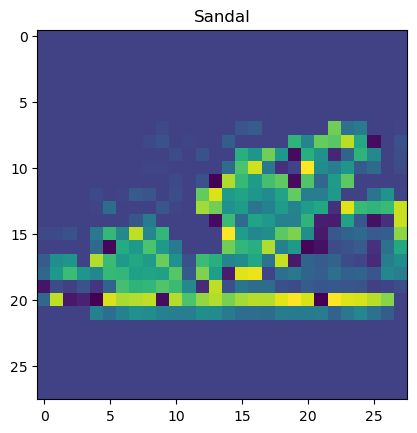

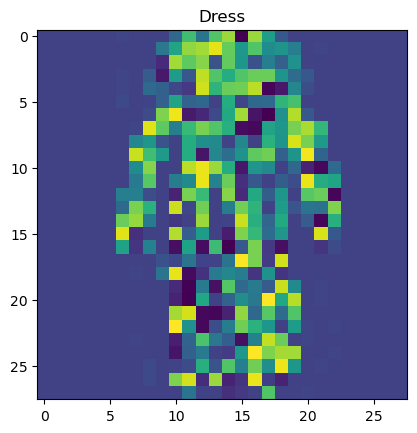

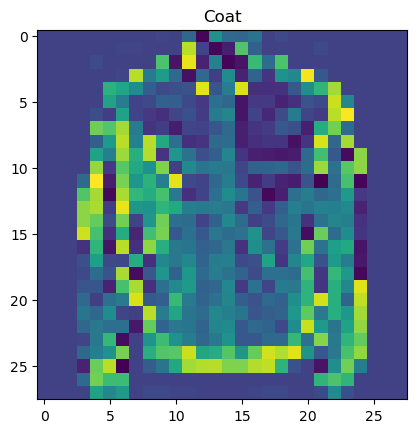

In [5]:
def display_image(array):
    array = array * 255
    array = np.uint8(array)
    plt.imshow(array)

for index in random.choice(X_train.shape[0], 3, replace=False):
    plt.figure()
    display_image(X_train[index])
    plt.title(class_names[y_train[index]])

## Training the model

Now we can begin training our Convolutional Neural Network.

In [6]:
cnn = models.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(128, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPool2D(pool_size=(2,2), padding='same'),
    layers.Conv2D(128, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPool2D(pool_size=(2,2), padding='same'),
    layers.Flatten(),
    layers.Dropout(0.5, seed=seed),
    layers.Dense(10),
])

cnn.summary()

I0000 00:00:1778156392.561622   65954 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        62,730 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,618 (830.54 KB)

 Trainable params: 212,106 (828.54 KB)

 Non-trainable params: 512 (2.00 KB)

In [7]:
cnn.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = cnn.fit(X_train, y_train, validation_split=0.2, epochs=30)

Epoch 1/30


I0000 00:00:1778156394.482567   66052 service.cc:153] XLA service 0x78bc0c035b30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778156394.482602   66052 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.9.0; DNN: 9.17.0)
I0000 00:00:1778156394.503815   66052 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778156394.638597   66052 cuda_dnn.cc:461] Loaded cuDNN version 91700
I0000 00:00:1778156394.675655   66052 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2193__.36


  42/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4836 - loss: 1.8857

I0000 00:00:1778156398.714316   66052 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8181 - loss: 0.5946 - val_accuracy: 0.8857 - val_loss: 0.3241
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8748 - loss: 0.3534 - val_accuracy: 0.8906 - val_loss: 0.3036
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8936 - loss: 0.2963 - val_accuracy: 0.8898 - val_loss: 0.2914
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9020 - loss: 0.2719 - val_accuracy: 0.9098 - val_loss: 0.2550
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9081 - loss: 0.2554 - val_accuracy: 0.9082 - val_loss: 0.2508
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9136 - loss: 0.2412 - val_accuracy: 0.9127 - val_loss: 0.2437
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9192 - loss: 0.2275 - val_accuracy: 0.9183 - val_loss: 0.2309
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9211 - loss: 0.2168 - val_accura

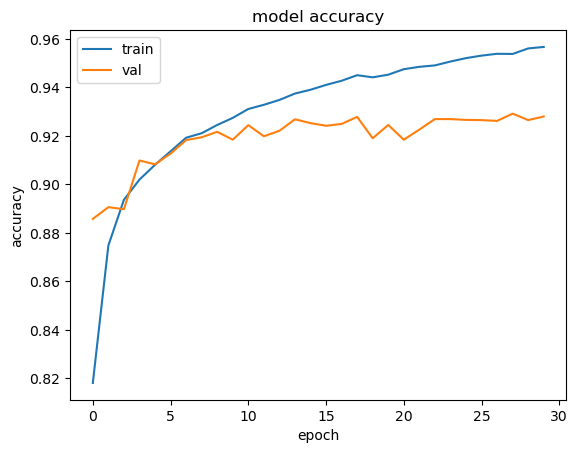

In [8]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'])
plt.show()

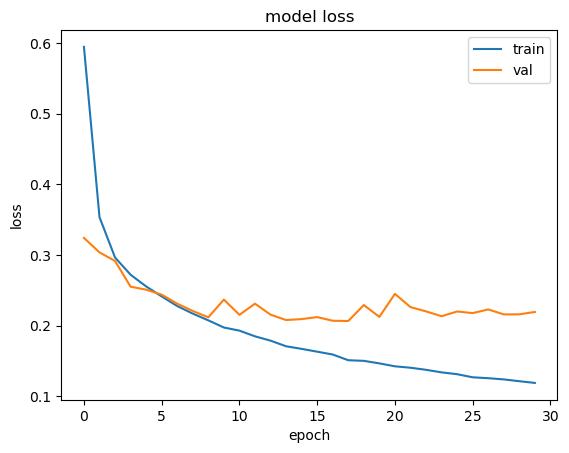

In [9]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'])
plt.show()

In [10]:
cnn.evaluate(X_test, y_test, verbose=2)

313/313 - 2s - 6ms/step - accuracy: 0.9238 - loss: 0.2416


[0.2416095733642578, 0.923799991607666]

## Employing SHAP values to explain the CNN

In [11]:
images_dict = dict()
for i, l in enumerate(y_train):
  if len(images_dict)==10:
    break
  if l not in images_dict.keys():
    images_dict[l] = X_train[i].reshape((28, 28))

X_test_dict = dict()
for i, l in enumerate(y_test):
  if len(X_test_dict)==10:
    break
  if l not in X_test_dict.keys():
    X_test_dict[l] = X_test[i]

X_test_each_class = [X_test_dict[i] for i in sorted(X_test_dict)]

X_test_each_class = np.asarray(X_test_each_class)

In [12]:
background = X_train[random.choice(X_train.shape[0], 100, replace=False)]

explainer = shap.DeepExplainer(cnn, background)
shap_values = explainer.shap_values(X_test_each_class)

/home/hoyt/anaconda3/envs/Exam/lib/python3.11/site-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/home/hoyt/anaconda3/envs/Exam/lib/python3.11/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(100, 28, 28, 1))']
  warnings.warn(msg)
/home/hoyt/anaconda3/envs/Exam/lib/python3.11/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(200, 28, 28, 1))']
  warnings.warn(msg)
/home/hoyt/anaconda3/envs/Exam/lib/python3.11/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected str

In [13]:
# Function to plot images
def plot_categories(images, class_names):
  fig, axes = plt.subplots(1, 11, figsize=(16, 15))
  axes = axes.flatten()
  
  # Plot an empty canvas
  ax = axes[0]
  dummy_array = np.array([[[0, 0, 0, 0]]], dtype='uint8')
  ax.set_title("reference")
  ax.set_axis_off()
  ax.imshow(dummy_array, interpolation='nearest')

  # Plot an image for every category
  for k,v in images.items():
    ax = axes[k+1]
    ax.imshow(v, cmap=plt.cm.binary)
    ax.set_title(f"{class_names[k]}")
    ax.set_axis_off()

  plt.tight_layout()
  plt.show()

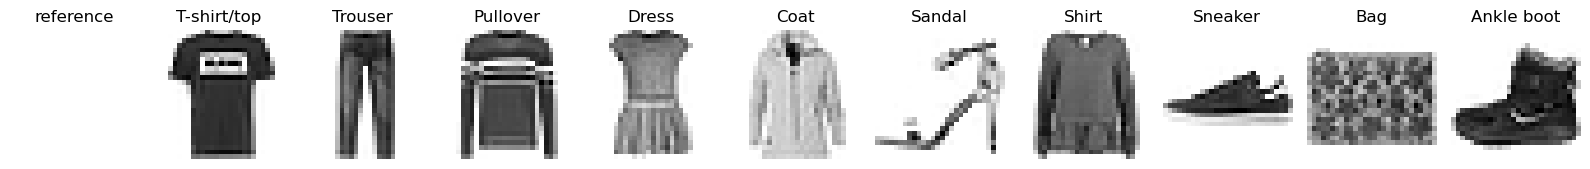

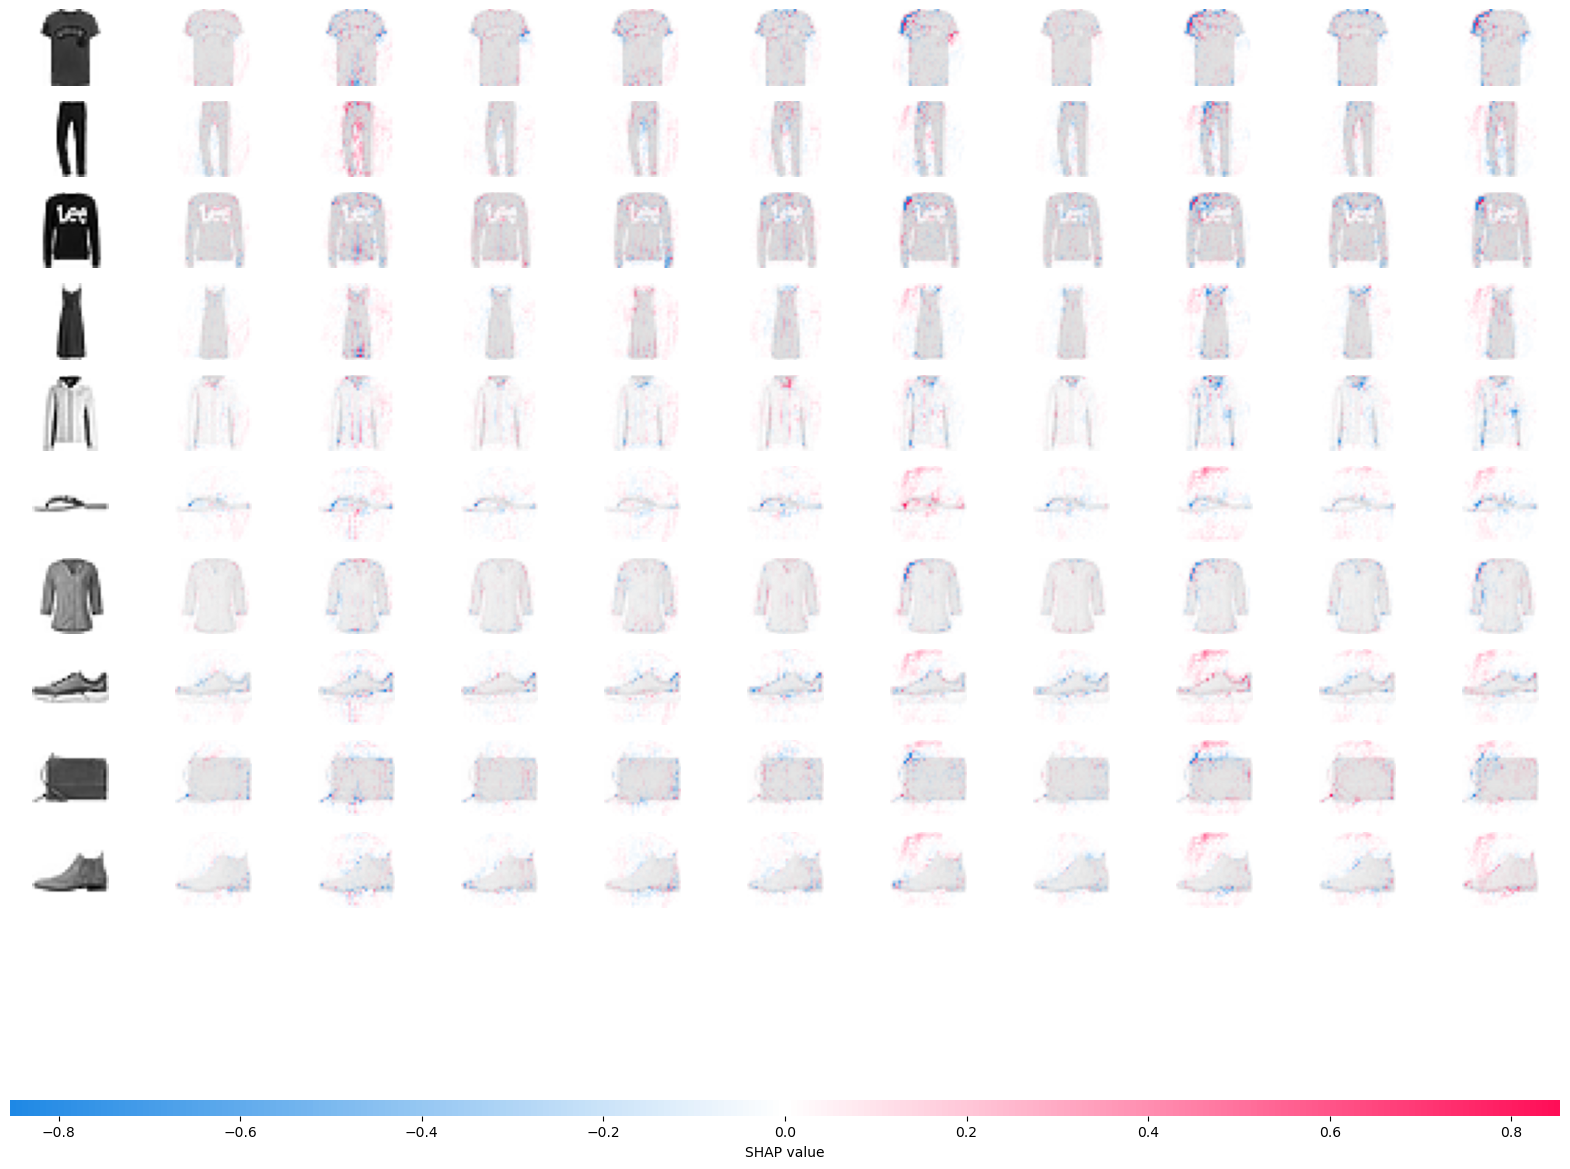

In [ ]:
# plot  class label list
plot_categories(images_dict, class_names)
# Plot SHAP values
shap_transposed = np.transpose(shap_values, (4, 0, 1, 2, 3))
shap_numpy = [np.array(arr) for arr in shap_transposed]
shap.image_plot(shap_numpy, -X_test_each_class)

It would seem that the model has learned that sleeves mark the difference between a pullover and a t-shirt. The ends of a t-shirt's short sleeves give negative SHAP values for pullover classification, and the ends of a pullover's long sleeves similarly give negative SHAP values for t-shirt classification.